In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import clear_output
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler


    hype-para-1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27     0.577766     0.428772     0.425826     0.249007        -4.025542    file
30     0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
31     0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32     0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24     0.326076     0.472367     0.453192     0.105887        -6.702089    file
23     0.282138     0.505987     0.530531     0.096302        -7.966775    file
4      0.124871     0.129770     0.384400     0.287076       -10.069633    file
21     0.170347     0.756959     0.276520     0.531231       -11.565742    file
2      0.250946     0.033693     0.145380     0.494932       -11.699932    file
6      0.247708     0.060445     0.042186     0.441324       -12.681685    file
9      0.626071     0.586751     0.438806     0.778858       -12.741766    file
16     0.216911     0.166086     0.24137

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_61328/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


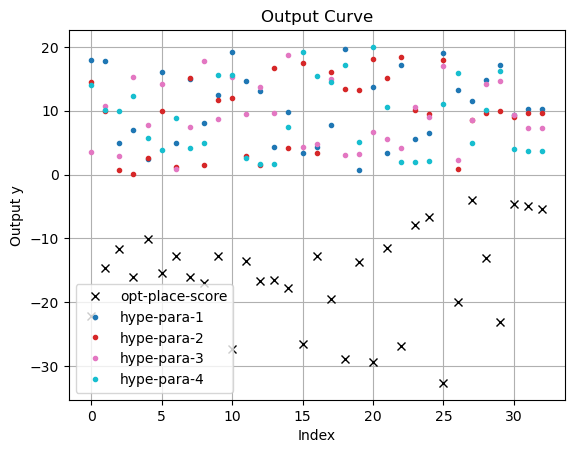

In [2]:
#Process data
%run data_handler.ipynb

In [3]:
X = inputs
y = outputs

In [4]:
%run ../common_functions.ipynb
# Initialize result collection
query_results = []

In [5]:
param_grid = [
    {'method': 'PI', 'xi': 0.01},
    {'method': 'PI', 'xi': 0.05},
    {'method': 'PI', 'xi': 0.1},
    {'method': 'UCB', 'kappa': 1.0},
    {'method': 'UCB', 'kappa': 2.0},
    {'method': 'UCB', 'kappa': 3.0},
    {'method': 'EI', 'xi': 0.1},
    {'method': 'EI', 'xi': 0.05},
    {'method': 'EI', 'xi': 0.1},
]

for params in param_grid:
    method = params['method']
    kwargs = {
        'X': X,
        'y': y,
        'method': method,
        'grid_size': 200,
        'dimension': X.shape[1] - 1,
        'filter_mode': 'median'
    }
    if method in ['PI', 'EI']:
        kwargs['xi'] = params['xi']
        label_param = params['xi']
    elif method == 'UCB':
        kwargs['kappa'] = params['kappa']
        label_param = params['kappa']

    next_point, acq_vals, grid = select_next_query_multi(**kwargs)
    score = acq_vals[np.argmax(acq_vals)]
    print("Next query point:", next_point)
    log_query_candidate(method, label_param, next_point, score)

Number of features:  4
Input space dimension: 4
Points before downsampling: 1600000000
Points after downsampling: 20151121
Final grid shape: (20151121, 4)
Filtered 3131339 candidates near decision boundary (|margin| < 0.2)
Excluded 17019782 candidates from consideration
Final grid shape: (3131339, 4)
Known data volume: 0.19209942612363415
Grid volume: 1.5672040804233487
Coverage ratio of known data to grid volume: 0.12257460819763968
Mean  3131339
Std   3131339
Next query point: [ 0.59535682 -0.0937496  -0.05781365 -0.01848344]
Number of features:  4
Input space dimension: 4
Points before downsampling: 1600000000
Points after downsampling: 20151121
Final grid shape: (20151121, 4)
Filtered 3131339 candidates near decision boundary (|margin| < 0.2)
Excluded 17019782 candidates from consideration
Final grid shape: (3131339, 4)
Known data volume: 0.19209942612363415
Grid volume: 1.5672040804233487
Coverage ratio of known data to grid volume: 0.12257460819763968
Mean  3131339
Std   3131339


In [6]:
param_grid = [
    {'method': 'PI', 'xi': 0.01},
    {'method': 'PI', 'xi': 0.05},
    {'method': 'PI', 'xi': 0.1},
    {'method': 'UCB', 'kappa': 1.0},
    {'method': 'UCB', 'kappa': 2.0},
    {'method': 'UCB', 'kappa': 3.0},
    {'method': 'EI', 'xi': 0.01},
    {'method': 'EI', 'xi': 0.05},
    {'method': 'EI', 'xi': 0.1},
]

for params in param_grid:
    method = params['method']
    kwargs = {
        'X': X,
        'y': y,
        'method': method,
        'grid_size': 50,
        'dimension': X.shape[1] - 1,
        'filter_mode': 'gp'
    }
    if method in ['PI', 'EI']:
        kwargs['xi'] = params['xi']
        label_param = params['xi']
    elif method == 'UCB':
        kwargs['kappa'] = params['kappa']
        label_param = params['kappa']

    next_point, acq_vals, grid = select_next_query_multi(**kwargs)
    score = acq_vals[np.argmax(acq_vals)]
    print("Next query point:", next_point)
    log_query_candidate(method, label_param, next_point, score)

Number of features:  4
Input space dimension: 4
Points before downsampling: 6250000
Points after downsampling: 83521
Final grid shape: (83521, 4)
Filtered 1437 candidates near decision boundary (|margin| < 0.2)
Excluded 82084 candidates from consideration
Final grid shape: (1437, 4)
Known data volume: 0.19209942612363415
Grid volume: 1.5672040804233487
Coverage ratio of known data to grid volume: 0.12257460819763968
Mean  1437
Std   1437
Next query point: [ 0.42973786  0.45156073 -0.05781365  1.07666693]
Number of features:  4
Input space dimension: 4
Points before downsampling: 6250000
Points after downsampling: 83521
Final grid shape: (83521, 4)
Filtered 1437 candidates near decision boundary (|margin| < 0.2)
Excluded 82084 candidates from consideration
Final grid shape: (1437, 4)
Known data volume: 0.19209942612363415
Grid volume: 1.5672040804233487
Coverage ratio of known data to grid volume: 0.12257460819763968
Mean  1437
Std   1437
Next query point: [ 0.42973786  0.45156073 -0.05

In [7]:
find_best_candidate(query_results)

Total number of points to evaluate: 18
{'method': 'PI', 'xi': 0.01, 'kappa': None, 'x': array([ 0.59535682, -0.0937496 , -0.05781365, -0.01848344]), 'score': 0.9999703453476783, 'dim': 4}
{'method': 'PI', 'xi': 0.05, 'kappa': None, 'x': array([ 0.59535682, -0.0937496 , -0.05781365, -0.01848344]), 'score': 0.9999648904431252, 'dim': 4}
{'method': 'PI', 'xi': 0.1, 'kappa': None, 'x': array([ 0.59535682, -0.0937496 , -0.05781365, -0.01848344]), 'score': 0.9999567326873224, 'dim': 4}
{'method': 'UCB', 'xi': None, 'kappa': 1.0, 'x': array([ 0.59535682, -0.0937496 , -0.05781365, -0.01848344]), 'score': 0.9999998390850903, 'dim': 4}
{'method': 'UCB', 'xi': None, 'kappa': 2.0, 'x': array([ 0.59535682, -0.0937496 , -0.05781365, -0.01848344]), 'score': 1.9999998390850902, 'dim': 4}
{'method': 'UCB', 'xi': None, 'kappa': 3.0, 'x': array([ 0.59535682, -0.0937496 , -0.05781365, -0.01848344]), 'score': 2.99999983908509, 'dim': 4}
{'method': 'EI', 'xi': 0.1, 'kappa': None, 'x': array([ 0.59535682, -0

{'method': 'EI',
 'xi': 0.01,
 'kappa': None,
 'x': array([ 0.42973786,  0.45156073, -0.05781365,  1.07666693]),
 'score': 4.015544035771805,
 'dim': 4}

In [8]:
#add points to dataframe
add_points_to_df(df_sorted, query_results)
pd.set_option('display.max_rows', None)
print(df_sorted)

    hype-para-1  hype-para-2  hype-para-3  hype-para-4  opt-place-score  source
27     0.577766     0.428772     0.425826     0.249007        -4.025542    file
30     0.469388     0.448980     0.469388     0.204082        -4.620232  week-1
31     0.515152     0.484848     0.363636     0.181819        -4.939960  week-2
32     0.515152     0.484848     0.363636     0.181819        -5.313374  week-3
24     0.326076     0.472367     0.453192     0.105887        -6.702089    file
23     0.282138     0.505987     0.530531     0.096302        -7.966775    file
4      0.124871     0.129770     0.384400     0.287076       -10.069633    file
21     0.170347     0.756959     0.276520     0.531231       -11.565742    file
2      0.250946     0.033693     0.145380     0.494932       -11.699932    file
6      0.247708     0.060445     0.042186     0.441324       -12.681685    file
9      0.626071     0.586751     0.438806     0.778858       -12.741766    file
16     0.216911     0.166086     0.24137

/var/folders/d6/s3jc1rb17y1411yjy8r6jlf80000gn/T/ipykernel_61328/923837372.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('tab10', len(other_cols))


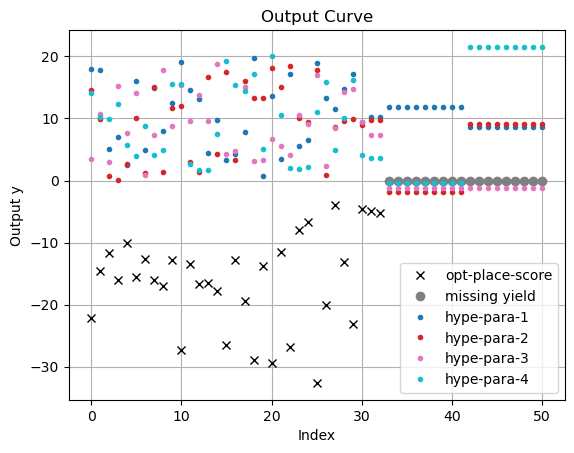

In [9]:
plot_output_points(df_sorted, scale_factor=20.0, yield_scale_factor=1.0)